# Investigation 08: PCA of Rules x FOVs

This notebook performs a Principal Component Analysis (PCA) on the spatial association rules across FOVs. It allows us to visualize how FOVs cluster based on their rule metrics and which rules are the strongest drivers of those clusters. We also use interactive Plotly charts to cleanly display the FOV names.

## 1. Imports & Configuration

Here we import necessary libraries and set the global parameters, including which metric to use for the PCA.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from sklearn.preprocessing import MinMaxScaler
import os
import sys
import ast
import warnings

warnings.filterwarnings('ignore')

# Add root to path for utils
sys.path.append(os.path.abspath('../../'))

# --- Global Parameters ---
# The metric to use for constructing the PCA feature matrix.
# Options include: 'Lift', 'Conviction', 'Support', 'Confidence'
METRIC_TO_USE = 'Lift'  
WITH_SCALE = True
NO_SELF = True

# Path to the weighted fpgrowth results
RESULTS_PATH = '../../results/full_run/weighted_fpgrowth/data/'


# --- Parameters ---
USE_FUNCTIONAL_MARKERS = False
CELLTYPE_MARKER_THRESHOLDS = {
    'Epithelial': {'Ki67': 2.5, 'HLADRDPDQ': 1.75},
    'CD8T': {'Ki67': 2.5, 'CD103': 2.0, 'CD69': 2.0, 'GZMB': 2.5},
    'CD4T': {'Ki67': 1.0, 'CD103': 1.0, 'CD69': 2.0, 'GZMB': 0.5},
    'Neutrophil': {'CD103': 2.75},
    'Neutrophil_CD15': {'CD103': 2.75}
}


## 2. Data Loading & Metadata

We load the algorithm results and merge the FOV and biopsy metadata to attach the `Organ` label to each FOV.

In [5]:
def load_results():
    print(f"Loading  results...")
    RESULT_CSV_PATH = os.path.join(RESULTS_PATH, 'results_CN.csv')
    

    if os.path.exists(RESULT_CSV_PATH):
        df_results = pd.read_csv(RESULT_CSV_PATH)
        print(f"Results loaded from {RESULT_CSV_PATH}")
    else:
        raise FileNotFoundError(f"Results file not found at {RESULT_CSV_PATH}")
        
    return df_results

def _add_functional_subtypes(df):
    if not USE_FUNCTIONAL_MARKERS:
        df["functional_subtypes"] = [[] for _ in range(len(df))]
        return df
    functional_subtypes_list = [[] for _ in range(len(df))]
    idx_to_pos = {idx: i for i, idx in enumerate(df.index)}
    for base_type, markers in CELLTYPE_MARKER_THRESHOLDS.items():
        type_mask = df["cell type"] == base_type
        for marker, threshold in markers.items():
            if marker in df.columns:
                mask = type_mask & (df[marker] > threshold)
                subtype_label = f"{base_type}_{marker}+"
                matching_indices = df.index[mask]
                for idx in matching_indices:
                    functional_subtypes_list[idx_to_pos[idx]].append(subtype_label)
    df["functional_subtypes"] = functional_subtypes_list
    return df

def get_clean_score(row, score_col):
    if pd.notna(row[score_col]):
        return str(row[score_col])
    if str(row['FOV']).startswith('S_'):
        return 'Control_S'
    return 'Control'

def get_organ(row):
    if pd.notna(row.get("Localization")): return row["Localization"]
    cohort = str(row.get("Cohort", ""))
    if "Colon" in cohort: return "Colon"
    if "Duodenum" in cohort: return "Duodenum"
    return "Unknown"

print("Loading spatial datasets...")
def get_data_dir():
    current_dir = os.path.abspath(os.getcwd())
    while current_dir != os.path.dirname(current_dir):
        potential_data = os.path.join(current_dir, 'data', 'MIBIGutCsv')
        if os.path.exists(potential_data):
            return potential_data
        current_dir = os.path.dirname(current_dir)
    return '../../data/MIBIGutCsv' 

data_dir = get_data_dir()
df_cells = pd.read_csv(os.path.join(data_dir, 'cell_table.csv'))
df_fovs = pd.read_csv(os.path.join(data_dir, 'fovs_metadata.csv'))
df_biopsy = pd.read_csv(os.path.join(data_dir, 'biopsy_metadata.csv'))

# Merge FOV with Biopsy
df_fovs = pd.merge(
    df_fovs,
    df_biopsy[['Biopsy_ID', 'Pathological score', 'Clinical score', 'Localization']],
    left_on='Patient',
    right_on='Biopsy_ID',
    how='left'
)
df_fovs["Organ"] = df_fovs.apply(get_organ, axis=1)
df_fovs["Pathological score"] = df_fovs.apply(lambda row: get_clean_score(row, "Pathological score"), axis=1)
df_fovs["Clinical score"] = df_fovs.apply(lambda row: get_clean_score(row, "Clinical score"), axis=1)

# Normalize Coordinates
fov_to_size = df_fovs.set_index('FOV')['Size [um]'].to_dict()
def normalize_coords(row):
    size = fov_to_size.get(row['fov'], 800)
    res = 1024 if size == 400 else 2048
    return row['centroid_x'] * (size / res), row['centroid_y'] * (size / res)

df_cells[['x_um', 'y_um']] = df_cells.apply(lambda row: pd.Series(normalize_coords(row)), axis=1)
df_cells = _add_functional_subtypes(df_cells)
print(f"Total Cells Loaded: {len(df_cells)}")

# Load Result Sets
df_results = load_results()

Loading spatial datasets...
Total Cells Loaded: 713372
Loading  results...
Results loaded from ../../results/full_run/weighted_fpgrowth/data/results_CN.csv


## 3. Matrix Construction & Preprocessing

We parse the rule strings to remove suffixes like `_CENTER` and `_NEIGHBOR`, pivot the table so that rows are FOVs and columns are rules, handle missing values appropriately for the selected metric, and scale the data.

In [6]:
def pca_matrix_construction(df_results):
    def clean_items(item_list_str):
        """
        Safely evaluates the string representation of a list, removes _CENTER and _NEIGHBOR suffixes,
        and returns a clean, comma-separated string regardless of how many items are in the list.
        """
        try:
            items = ast.literal_eval(item_list_str)
            cleaned = [item.replace('_CENTER', '').replace('_NEIGHBOR', '') for item in items]
            return ", ".join(sorted(cleaned))
        except Exception:
            return item_list_str

    print("Cleaning rule names...")
    df_results['Ant_Clean'] = df_results['Antecedents'].apply(clean_items)
    df_results['Con_Clean'] = df_results['Consequents'].apply(clean_items)
    df_results['Clean_Rule'] = df_results['Ant_Clean'] + " -> " + df_results['Con_Clean']

    if NO_SELF:
        print("Removing self-rules...")
        def has_overlap(row):
            ant_list = ast.literal_eval(row['Antecedents'])
            con_list = ast.literal_eval(row['Consequents'])

            # Clean the lists just like the clean_items function does
            ant_clean = {item.replace('_CENTER', '').replace('_NEIGHBOR', '') for item in ant_list}
            con_clean = {item.replace('_CENTER', '').replace('_NEIGHBOR', '') for item in con_list}
            
            return not ant_clean.isdisjoint(con_clean)

        overlap_mask = df_results.apply(has_overlap, axis=1)
        df_results = df_results[~overlap_mask].reset_index(drop=True)


    print("Pivoting data to create FOV x Rule matrix...")
    # Drop duplicates just in case there are multiple identical rules per FOV after cleaning
    df_pivot = df_results.drop_duplicates(subset=['FOV', 'Clean_Rule']) 
    feature_matrix = df_pivot.pivot(index='FOV', columns='Clean_Rule', values=METRIC_TO_USE)

    print(f"Matrix shape before NA fill: {feature_matrix.shape}")

    # Handle Missing Values
    # If a rule wasn't found in a FOV, we assign a baseline value depending on the metric.
    if METRIC_TO_USE in ['Lift', 'Conviction']:
        fill_value = 1.0  # 1.0 means no association
    else:
        fill_value = 0.0  # 0.0 means no support/confidence

    feature_matrix = feature_matrix.fillna(fill_value)

    # Ensure no infinite values (which can happen with Conviction)
    feature_matrix = feature_matrix.replace([np.inf, -np.inf], np.nan)
    max_val = feature_matrix.max().max()
    feature_matrix = feature_matrix.fillna(max_val * 1.1 if not pd.isna(max_val) else fill_value)

    if WITH_SCALE:
        # Scaling
        print("Scaling features using StandardScaler...")
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(feature_matrix)
        df_scaled = pd.DataFrame(scaled_data, index=feature_matrix.index, columns=feature_matrix.columns)
    else:
        # No scaling
        df_scaled = feature_matrix.copy()
        
    print(f"Final scaled matrix shape: {df_scaled.shape}")

    return df_scaled


## 4. PCA Calculation & Explained Variance

We run the PCA and plot the explained variance ratio (Scree Plot) to understand how much information is captured by the principal components.

In [21]:
def pca_explained_variance(df_scaled):
    print("Calculating PCA...")
    # Initialize PCA
    n_components = min(10, df_scaled.shape[0], df_scaled.shape[1])
    pca = PCA(n_components=n_components)
    pca_features = pca.fit_transform(df_scaled)

    # Create a DataFrame for the PCA results
    pca_columns = [f'PC{i+1}' for i in range(n_components)]
    df_pca = pd.DataFrame(pca_features, index=df_scaled.index, columns=pca_columns)

    # Merge back organ metadata for plotting
    df_pca_merged = df_pca.reset_index().merge(df_fovs[['FOV', 'Organ', 'Clinical score', 'Pathological score']], on='FOV', how='left')
    df_pca_merged['Organ'] = df_pca_merged['Organ'].fillna('Unknown')

    # Plot Explained Variance
    explained_variance = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(10, 5))
    plt.bar(pca_columns, explained_variance, color='skyblue', edgecolor='black')
    plt.plot(pca_columns, np.cumsum(explained_variance), color='red', marker='o', linestyle='-', label='Cumulative Variance')
    plt.suptitle('PCA Explained Variance (Scree Plot)', fontsize=14)
    plt.title(f'Metric: {METRIC_TO_USE} | Scaling: {"Yes" if WITH_SCALE else "No"} | No Self-Rules: {"Yes" if NO_SELF else "No"}', fontsize=10)
    plt.ylabel('Percentage of Variance Explained (%)', fontsize=12)
    plt.xlabel('Principal Components', fontsize=12)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return pca, df_pca_merged, explained_variance


## 5. Interactive PCA Scatter Plot

Using Plotly, we plot the FOVs based on their first two Principal Components. You can hover over any point to see the exact FOV name and its Organ.

In [23]:
def print_pca_plot(df_pca_merged, explained_variance, color_by='Organ'):
    # Create Interactive Scatter Plot with Plotly
    fig = px.scatter(
        df_pca_merged, 
        x='PC1', 
        y='PC2', 
        color=color_by,
        hover_name='FOV',
        title=f'PCA of FOVs based on Rule {METRIC_TO_USE}',
        subtitle=f'Color by: {color_by} | Scaling: {"Yes" if WITH_SCALE else "No"} | No Self-Rules: {"Yes" if NO_SELF else "No"}',
        labels={'PC1': f'PC1 ({explained_variance[0]:.1f}%)', 'PC2': f'PC2 ({explained_variance[1]:.1f}%)'},
        template='plotly_white',
        width=900,
        height=600
    )

    fig.update_traces(marker=dict(size=10, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))
    fig.show()


## 6. Principal Component Loadings (Weights)

To interpret what PC1 and PC2 actually represent, we extract their "loadings" (or weights). The loadings tell us which specific rules are pulling the FOVs along that axis.

In [24]:
def plot_pca_loadings(pca_model, component_idx, feature_names, top_n=10):
    """
    Plots the top positive and negative features (rules) driving a specific Principal Component.
    """
    # Extract weights for the specified component
    weights = pca_model.components_[component_idx]
    
    # Create a Series for easy sorting
    loading_series = pd.Series(weights, index=feature_names)
    
    # Get top positive and top negative loadings
    top_positive = loading_series.nlargest(top_n)
    top_negative = loading_series.nsmallest(top_n)
    
    # Combine them for plotting
    top_loadings = pd.concat([top_positive, top_negative]).sort_values()
    
    # Plotting
    colors = ['salmon' if val < 0 else 'mediumseagreen' for val in top_loadings.values]
    
    plt.figure(figsize=(12, 8))
    bars = plt.barh(top_loadings.index, top_loadings.values, color=colors, edgecolor='black')
    
    plt.suptitle(f'Top Rule Weights (Loadings) for PC{component_idx + 1}', fontsize=14)
    plt.title(f'Metric: {METRIC_TO_USE} | Scaling: {"Yes" if WITH_SCALE else "No"} | No Self-Rules: {"Yes" if NO_SELF else "No"}', fontsize=10)
    plt.xlabel('Weight (Contribution to PC)', fontsize=12)
    plt.ylabel('Rule', fontsize=12)
    plt.axvline(x=0, color='black', linewidth=1.2)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()



In [ ]:
def plot_all_pca_results(df_results, color_by=None):
    df_scaled = pca_matrix_construction(df_results)
    pca_model, df_pca_merged, explained_variance = pca_explained_variance(df_scaled)

    if color_by is not None:
        print_pca_plot(df_pca_merged, explained_variance, color_by)

    else:
        print_pca_plot(df_pca_merged, explained_variance, 'Organ')
        print_pca_plot(df_pca_merged, explained_variance, 'Pathological score')
        print_pca_plot(df_pca_merged, explained_variance, 'Clinical score')
    
    # Plot loadings for PC1
    plot_pca_loadings(pca_model, component_idx=0, feature_names=df_scaled.columns, top_n=10)

    # Plot loadings for PC2
    plot_pca_loadings(pca_model, component_idx=1, feature_names=df_scaled.columns, top_n=10)


## FOV Visualization

In [11]:
# Generate Global Colormap matching Notebook 05
all_types = sorted(df_cells["cell type"].dropna().astype(str).unique())
try:
    palette = plt.colormaps.get_cmap("tab20b").resampled(max(len(all_types), 1))
except AttributeError:
    palette = plt.cm.get_cmap("tab20b", max(len(all_types), 1))
CELL_COLOR_MAP = {ct: palette(i) for i, ct in enumerate(all_types)}
OTHER_COLOR = (0.5, 0.5, 0.5)

def add_scale_bar_50um(ax, x_max, y_max):
    bar_um = 50.0
    x_end = x_max - 25
    x_start = x_end - bar_um
    y_line = y_max - 25
    ax.plot([x_start, x_end], [y_line, y_line], color="black", linewidth=4, solid_capstyle="butt")
    ax.text((x_start + x_end) / 2, y_line - 12, "50 µm", color="black", ha="center", va="bottom", fontsize=10)

def plot_fov(fov_id, description, df_cells_all, df_fovs_all, target_ant_cells=None, target_cons_cells=None, ax=None):
    
    df_fov = df_cells_all[df_cells_all["fov"] == fov_id].copy()
    if df_fov.empty:
        print(f"No cells found for FOV {fov_id}")
        return
    
    size_um = df_fovs_all[df_fovs_all['FOV'] == fov_id]['Size [um]'].iloc[0] if not df_fovs_all[df_fovs_all['FOV'] == fov_id].empty else 400
    cell_size = 90 if size_um == 400 else 45

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10), facecolor="#ffffff")
        show_plot = True
    else:     
        show_plot = False

    ax.set_facecolor("#eaeaeaff")
    
    if target_ant_cells or target_cons_cells:
        title = f"Highlighted Rule in {fov_id}\n{', '.join(target_ant_cells)} -> {', '.join(target_cons_cells)}"
        # Background cells
        other_mask = ~df_fov['cell type'].isin(list(target_ant_cells) + list(target_cons_cells))
        if other_mask.any():
            g = df_fov[other_mask]
            ax.scatter(g["x_um"], g["y_um"], s=cell_size, c=[OTHER_COLOR], alpha=0.2, linewidths=0, label='Other')
            
        # Target cells
        target_mask = df_fov['cell type'].isin(list(target_ant_cells) + list(target_cons_cells))
        if target_mask.any():
            for ct, g in df_fov[target_mask].groupby("cell type"):
                color = CELL_COLOR_MAP.get(ct, (0, 0, 0))
                ax.scatter(g["x_um"], g["y_um"], s=cell_size, c=[color], label=ct, alpha=1.0, linewidths=0)
                
        handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=CELL_COLOR_MAP.get(ct, 'black'), markeredgecolor="none", markersize=8, label=ct) for ct in list(target_ant_cells) + list(target_cons_cells)]
    else:
        title = f"FOV: {fov_id}"
        if description:
            title += f" ({description})"
            
        for ct, g in df_fov.groupby("cell type"):
            color = CELL_COLOR_MAP.get(ct, (1, 1, 1))
            ax.scatter(g["x_um"], g["y_um"], s=cell_size, c=[color], label=ct, alpha=0.9, linewidths=0)
            
        present_types = sorted(df_fov["cell type"].dropna().astype(str).unique())
        handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=CELL_COLOR_MAP.get(ct, 'black'), markeredgecolor="none", markersize=8, label=ct) for ct in present_types]

    x_max, y_max = df_fov["x_um"].max(), df_fov["y_um"].max()
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(MultipleLocator(100.0))
    ax.yaxis.set_major_locator(MultipleLocator(100.0))
    ax.xaxis.set_minor_locator(MultipleLocator(25.0))
    ax.yaxis.set_minor_locator(MultipleLocator(25.0))
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8, alpha=0.7)
    ax.grid(which="major", color="lightgray", linestyle="-", linewidth=0.8, alpha=0.8)
    
    if not pd.isna(x_max) and not pd.isna(y_max):
        add_scale_bar_50um(ax, x_max=x_max, y_max=y_max)

    ax.set_title(title, color="black", fontsize=14)
    ax.set_xlabel("x (µm)", color="black")
    ax.set_ylabel("y (µm)", color="black")
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.tick_params(axis="both", colors="black", labelsize=9)
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.legend(handles=handles, title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, title_fontsize=10, frameon=True)
    
    if show_plot:
        plt.tight_layout()
        plt.show()

def print_fov_metadata(fov_id):
    fov_metadata = df_fovs[df_fovs['FOV'] == fov_id]
    if fov_metadata.empty:
        print(f"Error: FOV '{fov_id}' not found in metadata.")
        return
        
    meta = fov_metadata.iloc[0].to_dict()
    print("=" * 50)
    print(f"METADATA FOR FOV: {fov_id}")
    print("=" * 50)
    print(f"Cohort             : {meta.get('Cohort', 'Unknown')}")
    print(f"Patient / Biopsy ID: {meta.get('Patient', 'Unknown')}")
    print(f"Organ              : {meta.get('Organ', 'Unknown')}")
    print(f"Pathological Score : {meta.get('Pathological score', 'Unknown')}")
    print(f"Clinical Score     : {meta.get('Clinical score', 'Unknown')}")
    print(f"Size [um]          : {meta.get('Size [um]', 'Unknown')}")
    
    df_fov = df_cells[df_cells["fov"] == fov_id]
    print("-" * 50)
    print(f"Total Cells in FOV : {len(df_fov)}")
    print("=" * 50)



In [ ]:
def plot_pca_fovs(target_fovs = {}, num_cols = 1):
    num_plots = len(target_fovs)
    num_rows = (num_plots + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10 * num_cols, 10 * num_rows), facecolor="#ffffff")
    axes = axes.flatten()
    
    # plot full fov
    for i, target_fov in enumerate(target_fovs):
        
        description = target_fovs[target_fov]

        plot_fov(target_fov, description, df_cells, df_fovs, target_ant_cells=None, target_cons_cells=None, ax=axes[i])
    
    for i, ax in enumerate(axes):
        letter = chr(65 + i)  # 'A', 'B', 'C', ...
        ax.text(-0.05, 1.05, letter,
                transform=ax.transAxes, # IMPORTANT: This tells Matplotlib to use Axes coordinates (0 to 1) instead of your data's x/y coordinates
                fontsize=20, fontweight='bold', va='top', ha='right')
    plt.tight_layout()
    plt.show() 


## PCA for Lift, No Self

Cleaning rule names...
Removing self-rules...
Pivoting data to create FOV x Rule matrix...
Matrix shape before NA fill: (288, 587)
Scaling features using StandardScaler...
Final scaled matrix shape: (288, 587)
Calculating PCA...


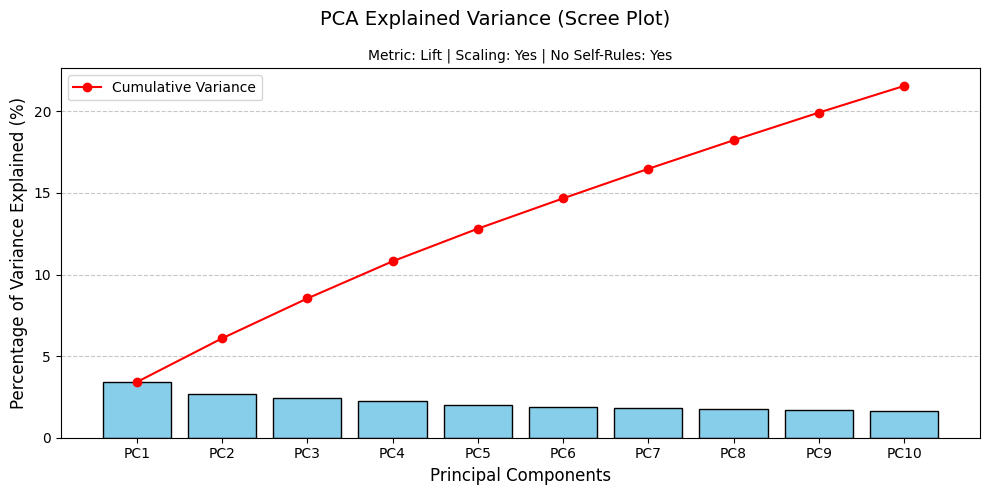

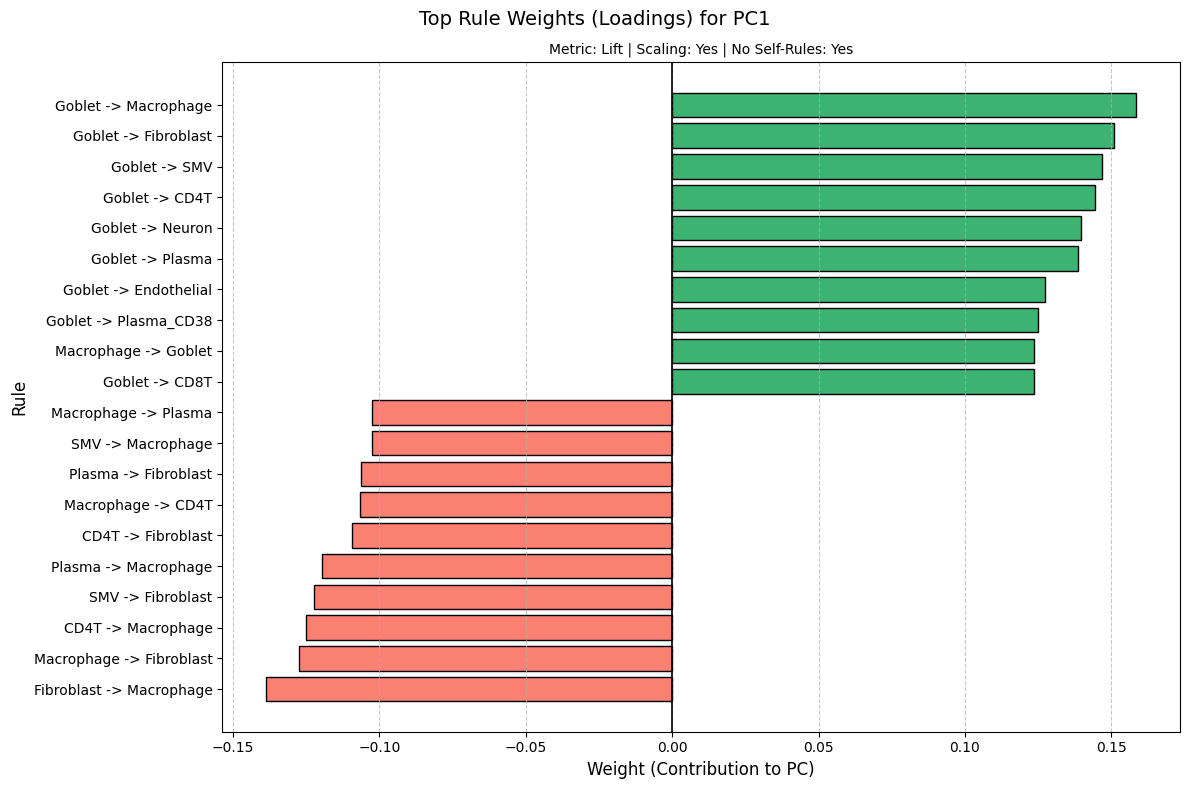

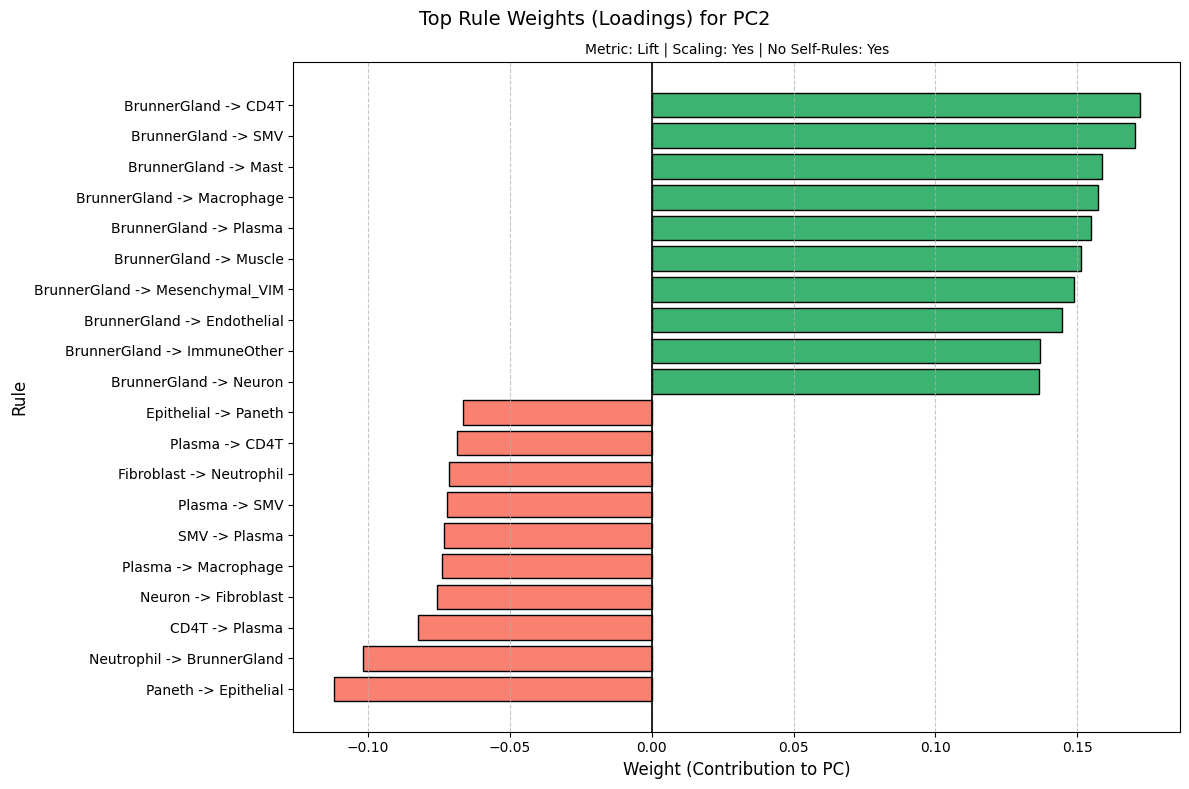

In [25]:
METRIC_TO_USE = 'Lift'  
WITH_SCALE = True
NO_SELF = True

plot_all_pca_results(df_results)

#### Print Polar FOVs

In [ ]:
fov_left = "GVHD_55_FOV_2"
fov_left_2 = "GVHD_57_FOV_4"
# fov_middle_left = "GVHD_47_FOV_1"
fov_middle_left = "GVHD_10_FOV_4"

fov_middle = "GVHD_58_FOV_3"
fov_middle_right = "GVHD_02_FOV_1_R"

fov_middle_bottom = "GVHD_55_FOV_3"
fov_middle_bottom_2 = "GVHD_24_FOV_4"


plot_pca_fovs(target_fovs = {
    fov_left: "Middle, left - Duodenum",
    fov_left_2: "Middle, less left - Duodenum",
    fov_middle_left: "Middle - Duodenum (1)",
    fov_middle: "Middle - Duodenum (2)",
    fov_middle_right: "Middle right - Duodenum",
}, num_cols=5)



In [ ]:
fov_right_top = "GVHD_06_FOV_2"
fov_right_top_colon = "GVHD_32_FOV_1"
fov_right_middle = "GVHD_44_FOV_2"
fov_right_middle_bottom = "GVHD_24_FOV_3"
fov_right_bottom = "Control_06_FOV_3"

plot_pca_fovs(target_fovs = {
    fov_right_top_colon: "Right top - Colon",
    fov_right_top: "Right top - Duodenum",
    fov_right_middle: "Right middle - Duodenum",
    fov_right_middle_bottom: "Right middle bottom - Duodenum",
    fov_right_bottom: "Right bottom - Duodenum"
}, num_cols=5)


# PCA for Conviction, No Self

In [ ]:
METRIC_TO_USE = 'Conviction'  
WITH_SCALE = True
NO_SELF = True

plot_all_pca_results(df_results)